# 09. Confidence Intervals and Uncertainty Quantification

A point estimate is not yet a decision. Once we estimate a mean, a rate, or a tail metric, we still need to ask: **how much uncertainty remains?** Confidence intervals are one of the main tools for answering that question.

We keep the same premium-support setting from the previous lectures. We will use interval estimates to communicate what the audit sample suggests, what it still leaves uncertain, and how that uncertainty should shape operational promises.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain a confidence interval as a repeated-sampling procedure with a distinct interpretation from posterior probability.
2. Construct and interpret a t-based interval for a sample mean.
3. Distinguish empirical coverage from the nominal confidence level.
4. Compare Wald, Wilson, and Clopper-Pearson intervals for a binomial proportion.
5. Use bootstrap percentile intervals when analytic standard errors are awkward or unreliable.
6. Recognize common interval misinterpretations in reports and dashboards.
7. Translate interval evidence into a defensible recommendation under decision guardrails.

## Mathematical Core: Estimators, Standard Errors, and Coverage

An interval estimate combines a point estimate with a measure of uncertainty. A common large-sample form is

$$
\text{estimate} \pm \text{critical value} \times \text{standard error}.
$$

For a sample mean with unknown variance, the familiar t interval is

$$
\bar{Y} \pm t_{1-\alpha/2,\, n-1}\frac{s}{\sqrt{n}}.
$$

For a binary outcome with sample proportion $\hat{p}$, the simple Wald interval is

$$
\hat{p} \pm z_{1-\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}},
$$

but this interval can behave poorly when events are rare or samples are small. Wilson and exact intervals often behave better.

The repeated-sampling idea behind confidence intervals is coverage:

$$
P_{\theta}\left(\theta \in C(X_1, \ldots, X_n)\right) \approx 1 - \alpha.
$$

The probability statement is about the random interval before the data are observed. After a particular interval is computed, the parameter is either inside that interval or it is not. That distinction is subtle, but it matters when we communicate uncertainty to decision makers.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

rng = np.random.default_rng(2026)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Why Intervals Exist

We will build a synthetic population of premium-support tickets and then pretend we only observed one audit sample from it. That lets us compare three objects cleanly:

- the **population truth**, which we know only because this is a teaching simulation;
- the **sample estimate**, which is what an analyst actually gets from one audit; and
- the **interval estimate**, which expresses the range of values that remain plausible under repeated sampling.

Intervals are useful because one sample can support some claims strongly and other claims only weakly.

In [2]:
# Define helper functions so repeated calculations stay readable.
def make_support_population(n=140_000, seed=2026):
    """
    Construct the support population object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame representing the simulated support population, including covariates, operational outcomes, and ground-truth targets used later for inference checks.
    
    Idea:
        Create a known synthetic population so sample estimates, intervals, likelihoods, and inference procedures can be checked against ground truth.
    """
    local_rng = np.random.default_rng(seed)

    seller_tier = local_rng.choice(["standard", "priority", "strategic"], size=n, p=[0.58, 0.30, 0.12])
    channel = local_rng.choice(["chat", "email", "phone"], size=n, p=[0.42, 0.38, 0.20])
    severity = local_rng.choice(["low", "medium", "high", "urgent"], size=n, p=[0.36, 0.33, 0.22, 0.09])
    queue_load = local_rng.normal(0, 1, size=n)
    outage = local_rng.binomial(1, 0.055, size=n)

    seller_effect = pd.Series(seller_tier).map({"standard": 3.0, "priority": 1.4, "strategic": 0.2}).to_numpy()
    channel_effect = pd.Series(channel).map({"chat": -0.5, "email": 1.4, "phone": 1.8}).to_numpy()
    severity_effect = pd.Series(severity).map({"low": 0.0, "medium": 3.2, "high": 7.4, "urgent": 12.0}).to_numpy()

    noise = local_rng.gamma(shape=2.1, scale=1.7, size=n)
    outage_delay = outage * local_rng.lognormal(mean=2.15, sigma=0.5, size=n)

    response_minutes = (
        6.5
        + seller_effect
        + channel_effect
        + severity_effect
        + 1.3 * np.maximum(queue_load, -1.0)
        + noise
        + outage_delay
    )
    response_minutes = np.clip(response_minutes, 1, None)

    sla_threshold = pd.Series(severity).map({"low": 14, "medium": 18, "high": 25, "urgent": 34}).to_numpy()
    sla_breach = (response_minutes > sla_threshold).astype(int)

    manual_escalation = local_rng.binomial(
        1,
        np.clip(
            0.012
            + 0.06 * sla_breach
            + 0.04 * (np.array(severity) == "urgent")
            + 0.025 * (np.array(seller_tier) == "strategic"),
            0,
            0.95,
        ),
    )

    credit_flag = local_rng.binomial(
        1,
        np.clip(
            0.005
            + 0.05 * sla_breach
            + 0.025 * outage
            + 0.01 * (np.array(severity) == "urgent"),
            0,
            0.90,
        ),
    )

    return pd.DataFrame(
        {
            "seller_tier": seller_tier,
            "channel": channel,
            "severity": severity,
            "queue_load": queue_load,
            "outage": outage,
            "response_minutes": response_minutes,
            "sla_breach": sla_breach,
            "manual_escalation": manual_escalation,
            "credit_flag": credit_flag,
        }
    )


def support_metrics(frame):
    """
    Compute the support metrics quantity used in the statistical or decision-science workflow.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
    
    Returns:
        A dictionary of support-operation metrics such as response time, breach rate, tail response time, and service-credit exposure.
    
    Idea:
        Collect service metrics that matter together, emphasizing that decision quality depends on averages, tails, and failure rates.
    """
    return {
        "Mean response minutes": frame["response_minutes"].mean(),
        "Median response minutes": frame["response_minutes"].median(),
        "90th percentile response minutes": frame["response_minutes"].quantile(0.90),
        "SLA breach rate": frame["sla_breach"].mean(),
        "Goodwill credit flag rate": frame["credit_flag"].mean(),
    }


population = make_support_population()
audit_sample = population.sample(n=900, random_state=77).reset_index(drop=True)

population_truth = pd.Series(support_metrics(population), name="population_truth")
audit_estimate = pd.Series(support_metrics(audit_sample), name="audit_sample_estimate")

overview = pd.concat([population_truth, audit_estimate], axis=1)
overview["estimation_error"] = overview["audit_sample_estimate"] - overview["population_truth"]
smart_display(overview)

,population_truth,audit_sample_estimate,estimation_error
Mean response minutes,17.3384,17.4711,0.1328
Median response minutes,16.5396,16.8691,0.3295
90th percentile response minutes,24.5959,24.6759,0.0800
SLA breach rate,0.2585,0.2700,0.0115
Goodwill credit flag rate,0.0206,0.0244,0.0038


### Dataset and Experiment Design

The synthetic population is a premium-support environment with response-time outcomes, breach indicators, and enough heterogeneity to make uncertainty nontrivial. We use it because confidence intervals are easiest to understand when we can distinguish three objects: the unknown population quantity, the estimate from one sample, and the interval procedure that would be repeated across many possible samples.

The experiments here use repeated sampling, proportion intervals, and bootstrap resampling. Each experiment answers a slightly different question. Repeated sampling shows long-run coverage. Proportion intervals show why rare events require care. Bootstrap intervals show how uncertainty can be approximated when the statistic is more complicated than a simple mean.

The population truth is visible only because this is a teaching simulation. In real work, that truth is hidden, which is exactly why interval language has to be disciplined. The interval is not decoration around a point estimate. It is part of the evidence.

## 2. One Realized Interval for the Mean

For a sample mean, the most familiar interval is the t-based interval:

$$
\bar{x} \pm t_{0.975,\,n-1} \times \frac{s}{\sqrt{n}}.
$$

This formula uses the sample standard deviation to estimate the standard error of the mean. In repeated sampling, intervals built by this rule are designed to contain the true population mean about 95% of the time.

The 95% statement belongs to the procedure across repeated samples. After the data are observed, this realized interval either covers the population mean or misses it.

In [3]:
# Build a summary table that supports the interpretation in the surrounding notes.
n_audit = len(audit_sample)
audit_mean = audit_sample["response_minutes"].mean()
audit_sd = audit_sample["response_minutes"].std(ddof=1)
audit_se = audit_sd / np.sqrt(n_audit)
t_critical = stats.t.ppf(0.975, df=n_audit - 1)

mean_ci_low = audit_mean - t_critical * audit_se
mean_ci_high = audit_mean + t_critical * audit_se

mean_interval_table = pd.DataFrame(
    [
        {
            "quantity": "Mean response minutes",
            "sample_estimate": audit_mean,
            "standard_error": audit_se,
            "ci_low": mean_ci_low,
            "ci_high": mean_ci_high,
            "population_truth": population_truth["Mean response minutes"],
            "contains_truth": mean_ci_low <= population_truth["Mean response minutes"] <= mean_ci_high,
        }
    ]
)
smart_display(mean_interval_table)

,quantity,sample_estimate,standard_error,ci_low,ci_high,population_truth,contains_truth
0,Mean response minutes,17.4711,0.1820,17.1140,17.8283,17.3384,True


The interval above is one realized object from one audit. It is useful because it communicates both the point estimate and the sampling uncertainty around it.

Notice the discipline here:

- the **estimate** tells us where the audit landed;
- the **standard error** tells us how much that estimate tends to fluctuate across comparable audits; and
- the **interval** translates that fluctuation into a range that is easier to communicate in meetings and memos.

Intervals are therefore not anti-decision. They are decision tools that prevent false precision.

## 3. Repeated-Sampling Coverage for Mean Intervals

Confidence intervals are best understood procedurally. We will repeatedly draw audit samples from the same population, compute a 95% t interval each time, and then ask two questions:

1. how often does the interval cover the true mean? 
2. how wide is the interval at different sample sizes?

That makes the repeated-sampling logic visible.

In [4]:
# Define helper functions so repeated calculations stay readable.
def mean_t_interval(sample):
    """
    Compute a t-based confidence interval for a sample mean.
    
    Parameters:
        sample: Observed sample used to compute the interval, bootstrap statistic, or test quantity.
    
    Returns:
        A tuple containing the sample mean and the lower and upper endpoints of the t confidence interval.
    
    Idea:
        Use the t interval to account for estimating the standard deviation from the same sample used to estimate the mean.
    """
    n = len(sample)
    mean = sample["response_minutes"].mean()
    se = sample["response_minutes"].std(ddof=1) / np.sqrt(n)
    critical = stats.t.ppf(0.975, df=n - 1)
    return mean, mean - critical * se, mean + critical * se


truth_mean = population_truth["Mean response minutes"]
coverage_rows = []
example_rows = []
sample_sizes = [60, 180, 600]
indices = np.arange(len(population))

for n in sample_sizes:
    widths = []
    covers = []
    for draw in range(400):
        chosen = rng.choice(indices, size=n, replace=False)
        sample = population.iloc[chosen]
        mean, low, high = mean_t_interval(sample)
        cover = low <= truth_mean <= high
        widths.append(high - low)
        covers.append(cover)

        if n == 60 and draw < 60:
            example_rows.append(
                {
                    "draw": draw + 1,
                    "estimate": mean,
                    "ci_low": low,
                    "ci_high": high,
                    "covers_truth": cover,
                }
            )

    coverage_rows.append(
        {
            "sample_size": n,
            "empirical_coverage": np.mean(covers),
            "average_interval_width": np.mean(widths),
            "median_interval_width": np.median(widths),
        }
    )

coverage_summary = pd.DataFrame(coverage_rows)
interval_examples = pd.DataFrame(example_rows)

smart_display(coverage_summary)

,sample_size,empirical_coverage,average_interval_width,median_interval_width
0,60,0.9500,2.8248,2.7833
1,180,0.9225,1.6041,1.5902
2,600,0.9500,0.8769,0.8751


These repeated samples make the main warning visible. The same data-generating process can produce noticeably different audit summaries. One sample is evidence about the process, not the process itself.


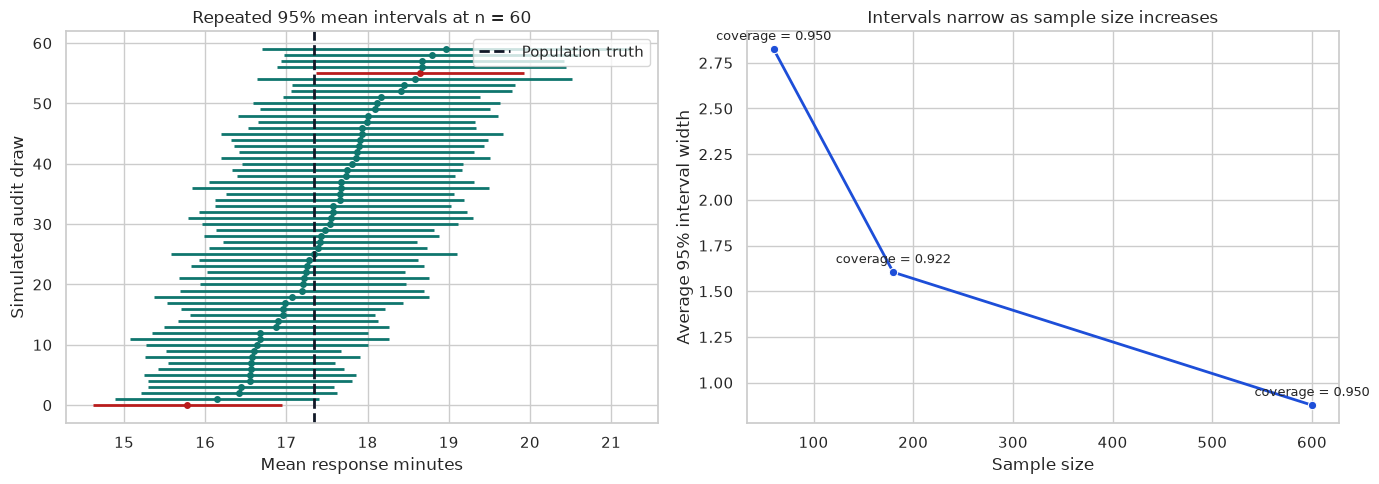

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

subset = interval_examples.sort_values("estimate").reset_index(drop=True)
for idx, row in subset.iterrows():
    color = "#0f766e" if row["covers_truth"] else "#b91c1c"
    axes[0].hlines(y=idx, xmin=row["ci_low"], xmax=row["ci_high"], color=color, linewidth=2)
    axes[0].plot(row["estimate"], idx, "o", color=color, markersize=4)

axes[0].axvline(truth_mean, color="#111827", linestyle="--", linewidth=2, label="Population truth")
axes[0].set_title("Repeated 95% mean intervals at n = 60")
axes[0].set_xlabel("Mean response minutes")
axes[0].set_ylabel("Simulated audit draw")
axes[0].legend()

sns.lineplot(
    data=coverage_summary,
    x="sample_size",
    y="average_interval_width",
    marker="o",
    linewidth=2,
    ax=axes[1],
    color="#1d4ed8",
)
for _, row in coverage_summary.iterrows():
    axes[1].text(
        row["sample_size"],
        row["average_interval_width"] + 0.05,
        f"coverage = {row['empirical_coverage']:.3f}",
        ha="center",
        fontsize=9,
    )
axes[1].set_title("Intervals narrow as sample size increases")
axes[1].set_xlabel("Sample size")
axes[1].set_ylabel("Average 95% interval width")

plt.tight_layout()
plt.show()

Three lessons matter here.

First, the interval procedure covers the true mean most of the time, but not all of the time. That is exactly what a 95% confidence procedure promises.

Second, the coverage is not magically exact in every finite sample setting. With skewed operational data, the realized coverage in a simulation can drift a bit above or below 95%.

Third, interval width shrinks as the audit gets larger. Bigger samples compress uncertainty.

## 4. Proportion Intervals: Wald, Wilson, and Clopper-Pearson

Binary rates are everywhere in operations: breach rates, defect rates, approval rates, fraud rates, escalation rates. The default Wald interval is often taught first, but it can behave badly for small samples or rare events.

To make that failure visible, we will look at a **small pilot audit** for a rare event, the goodwill-credit flag rate. Then we will compare three interval constructions:

- **Wald**: simple and common, but fragile;
- **Wilson**: usually far more stable in finite samples;
- **Clopper-Pearson**: conservative exact interval based on binomial tails.

In [6]:
# Define helper functions so repeated calculations stay readable.
def wald_interval(x, n, alpha=0.05):
    """
    Compute a large-sample Wald confidence interval for a proportion.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
        n: Number of observations, rows, or simulated units to generate.
        alpha: Significance level, regularization strength, or model parameter as defined by the calling cell.
    
    Returns:
        A tuple containing the lower and upper endpoints of the Wald interval for the sample proportion.
    
    Idea:
        Show the basic normal-approximation interval for a proportion, useful because its simplicity also reveals when it can fail.
    """
    z = stats.norm.ppf(1 - alpha / 2)
    p = x / n
    se = np.sqrt(p * (1 - p) / n)
    return p - z * se, p + z * se


def wilson_interval(x, n, alpha=0.05):
    """
    Compute a Wilson confidence interval for a proportion.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
        n: Number of observations, rows, or simulated units to generate.
        alpha: Significance level, regularization strength, or model parameter as defined by the calling cell.
    
    Returns:
        A tuple containing the lower and upper endpoints of the Wilson score interval for the sample proportion.
    
    Idea:
        Use the Wilson interval as a better-behaved proportion interval when Wald intervals become unstable near boundaries or small samples.
    """
    z = stats.norm.ppf(1 - alpha / 2)
    p = x / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return center - half, center + half


def clopper_pearson_interval(x, n, alpha=0.05):
    """
    Compute an exact Clopper-Pearson confidence interval for a proportion.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
        n: Number of observations, rows, or simulated units to generate.
        alpha: Significance level, regularization strength, or model parameter as defined by the calling cell.
    
    Returns:
        A tuple containing the lower and upper endpoints of the exact Clopper-Pearson binomial interval.
    
    Idea:
        Use exact binomial inversion as a conservative benchmark for proportion uncertainty, especially when normal approximations are fragile.
    """
    lower = 0.0 if x == 0 else stats.beta.ppf(alpha / 2, x, n - x + 1)
    upper = 1.0 if x == n else stats.beta.ppf(1 - alpha / 2, x + 1, n - x)
    return lower, upper


pilot_sample = audit_sample.sample(n=60, random_state=101)
pilot_successes = int(pilot_sample["credit_flag"].sum())
pilot_n = len(pilot_sample)
pilot_rate = pilot_successes / pilot_n

example_interval_table = pd.DataFrame(
    [
        {"method": "Wald", "low": wald_interval(pilot_successes, pilot_n)[0], "high": wald_interval(pilot_successes, pilot_n)[1]},
        {"method": "Wilson", "low": wilson_interval(pilot_successes, pilot_n)[0], "high": wilson_interval(pilot_successes, pilot_n)[1]},
        {"method": "Clopper-Pearson", "low": clopper_pearson_interval(pilot_successes, pilot_n)[0], "high": clopper_pearson_interval(pilot_successes, pilot_n)[1]},
    ]
)
example_interval_table.insert(1, "successes", pilot_successes)
example_interval_table.insert(2, "n", pilot_n)
example_interval_table.insert(3, "observed_rate", pilot_rate)
smart_display(example_interval_table)

,method,successes,n,observed_rate,low,high
0,Wald,2,60,0.0333,-0.0121,0.0788
1,Wilson,2,60,0.0333,0.0092,0.1136
2,Clopper-Pearson,2,60,0.0333,0.0041,0.1153


The interval is the decision-relevant part of the answer, not decoration around a point estimate. It shows a range of plausible mean outcomes under repeated sampling, which is exactly what a stakeholder needs when a recommendation depends on a threshold.

If the whole interval sits on one side of the threshold, the recommendation can be stronger. If the interval overlaps the threshold, the honest recommendation should describe the remaining uncertainty and may call for a smaller rollout, more data, or a guardrail.


In [7]:
# Simulate data or resample observations to study variability and uncertainty.
true_credit_rate = population_truth["Goodwill credit flag rate"]
prop_rows = []

for n in [40, 120, 400]:
    method_records = {"sample_size": n}
    width_records = {"sample_size": n}

    for method in ["Wald", "Wilson", "Clopper-Pearson"]:
        covers = []
        widths = []
        for _ in range(2000):
            x = rng.binomial(n, true_credit_rate)
            if method == "Wald":
                low, high = wald_interval(x, n)
            elif method == "Wilson":
                low, high = wilson_interval(x, n)
            else:
                low, high = clopper_pearson_interval(x, n)
            covers.append(low <= true_credit_rate <= high)
            widths.append(high - low)

        method_records[f"{method} coverage"] = np.mean(covers)
        width_records[f"{method} avg width"] = np.mean(widths)

    prop_rows.append({**method_records, **width_records})

prop_coverage_summary = pd.DataFrame(prop_rows)
smart_display(prop_coverage_summary)

,sample_size,Wald coverage,Wilson coverage,Clopper-Pearson coverage,Wald avg width,Wilson avg width,Clopper-Pearson avg width
0,40,0.5495,0.9510,0.9915,0.0619,0.1159,0.1205
1,120,0.9220,0.9635,0.9865,0.0470,0.0564,0.0594
2,400,0.9120,0.9505,0.9710,0.0275,0.0288,0.0304


The coverage result explains what confidence means operationally. A 95% procedure is not promising that the one interval on screen has a 95% chance of containing the fixed truth. It is saying that the method captures the target in about 95% of repeated samples under its assumptions.

That distinction matters in reporting. The interval should be treated as a calibrated procedure-level uncertainty statement, not as a guarantee that the current sample has resolved the decision.


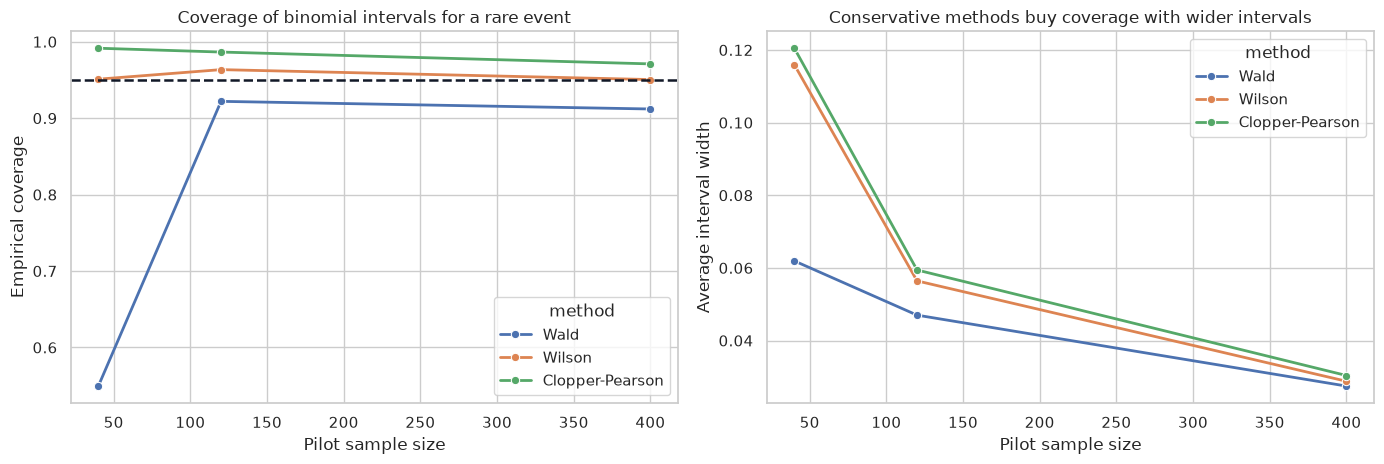

In [8]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

coverage_long = prop_coverage_summary.melt(
    id_vars="sample_size",
    value_vars=["Wald coverage", "Wilson coverage", "Clopper-Pearson coverage"],
    var_name="method",
    value_name="coverage",
)
coverage_long["method"] = coverage_long["method"].str.replace(" coverage", "", regex=False)

width_long = prop_coverage_summary.melt(
    id_vars="sample_size",
    value_vars=["Wald avg width", "Wilson avg width", "Clopper-Pearson avg width"],
    var_name="method",
    value_name="avg_width",
)
width_long["method"] = width_long["method"].str.replace(" avg width", "", regex=False)

sns.lineplot(data=coverage_long, x="sample_size", y="coverage", hue="method", marker="o", linewidth=2, ax=axes[0])
axes[0].axhline(0.95, color="#111827", linestyle="--", linewidth=1.8, label="Nominal 95%")
axes[0].set_title("Coverage of binomial intervals for a rare event")
axes[0].set_ylabel("Empirical coverage")
axes[0].set_xlabel("Pilot sample size")

sns.lineplot(data=width_long, x="sample_size", y="avg_width", hue="method", marker="o", linewidth=2, ax=axes[1])
axes[1].set_title("Conservative methods buy coverage with wider intervals")
axes[1].set_ylabel("Average interval width")
axes[1].set_xlabel("Pilot sample size")

plt.tight_layout()
plt.show()

The pilot-audit example shows exactly why Wald intervals deserve caution. With only two rare events in sixty cases, the Wald lower endpoint even falls below zero, which is not meaningful for a probability.

The simulation summary makes the practical tradeoff clearer:

- **Wald** intervals can be too optimistic and under-cover badly.
- **Wilson** intervals usually recover much better coverage without becoming excessively wide.
- **Clopper-Pearson** intervals are conservative: they cover reliably, but they are often wider than necessary.

For operational reporting, Wilson intervals are often a very good default when the quantity is a binomial rate.

## 5. Bootstrap Intervals for Harder Statistics

Some statistics have clean analytic standard errors. Others do not. Extreme quantiles are a classic example.

A bootstrap percentile interval avoids hand-derived formulas. We repeatedly resample the audit with replacement, recompute the statistic, and use the empirical quantiles of the bootstrap distribution as interval endpoints.

That does not make bootstrap magical. It still inherits the strengths and weaknesses of the observed sample. But for irregular targets like the 90th percentile, it is often a practical and defensible tool.

In [9]:
# Define helper functions so repeated calculations stay readable.
def bootstrap_statistic(sample, stat_fn, n_boot=1500, seed=404):
    """
    Generate bootstrap-based statistic results from resampled data.
    
    Parameters:
        sample: Observed sample used to compute the interval, bootstrap statistic, or test quantity.
        stat_fn: Statistic function applied to each bootstrap resample.
        n_boot: Sample size or group size used by the simulation, resampling, or inference step.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A NumPy array of bootstrap statistic values computed from resampled observations.
    
    Idea:
        Bootstrap a custom statistic so uncertainty can be studied even when a simple closed-form standard error is unavailable.
    """
    local_rng = np.random.default_rng(seed)
    values = []
    n = len(sample)
    for _ in range(n_boot):
        chosen = local_rng.choice(n, size=n, replace=True)
        values.append(stat_fn(sample.iloc[chosen]))
    return np.asarray(values)


bootstrap_mean = bootstrap_statistic(audit_sample, lambda s: s["response_minutes"].mean(), n_boot=1500, seed=900)
bootstrap_p90 = bootstrap_statistic(audit_sample, lambda s: s["response_minutes"].quantile(0.90), n_boot=1500, seed=901)

bootstrap_interval_table = pd.DataFrame(
    [
        {
            "metric": "Mean response minutes (t interval)",
            "estimate": audit_mean,
            "ci_low": mean_ci_low,
            "ci_high": mean_ci_high,
            "population_truth": truth_mean,
        },
        {
            "metric": "Mean response minutes (bootstrap percentile)",
            "estimate": audit_mean,
            "ci_low": np.quantile(bootstrap_mean, 0.025),
            "ci_high": np.quantile(bootstrap_mean, 0.975),
            "population_truth": truth_mean,
        },
        {
            "metric": "90th percentile response minutes (bootstrap percentile)",
            "estimate": audit_sample["response_minutes"].quantile(0.90),
            "ci_low": np.quantile(bootstrap_p90, 0.025),
            "ci_high": np.quantile(bootstrap_p90, 0.975),
            "population_truth": population_truth["90th percentile response minutes"],
        },
    ]
)
bootstrap_interval_table["contains_truth"] = (
    (bootstrap_interval_table["ci_low"] <= bootstrap_interval_table["population_truth"])
    & (bootstrap_interval_table["population_truth"] <= bootstrap_interval_table["ci_high"])
)
smart_display(bootstrap_interval_table)

,metric,estimate,ci_low,ci_high,population_truth,contains_truth
0,Mean response minutes (t interval),17.4711,17.1140,17.8283,17.3384,True
1,Mean response minutes (bootstrap percentile),17.4711,17.1159,17.8306,17.3384,True
2,90th percentile response minutes (bootstrap pe...,24.6759,23.9038,25.2465,24.5959,True


The simulation shows why uncertainty grows when the underlying outcome is noisy or the sample is small. The point estimate can jump from sample to sample, and the interval is the device that keeps that instability visible.

For decision-making, this means precision is not just a statistical luxury. It controls whether the analysis can separate a meaningful operational improvement from ordinary sample fluctuation.


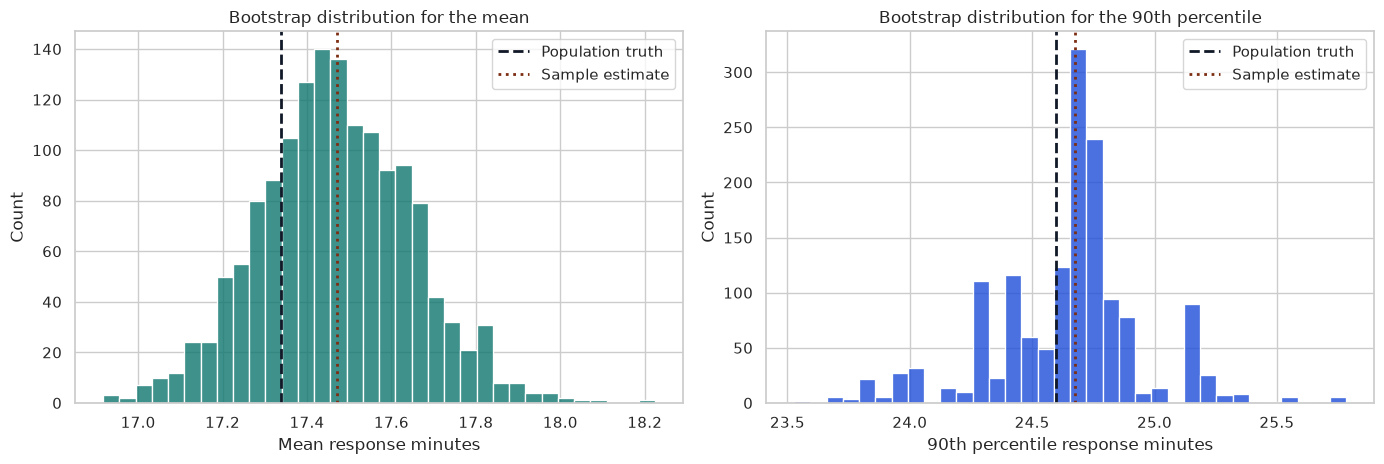

In [10]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.histplot(bootstrap_mean, bins=34, color="#0f766e", alpha=0.80, ax=axes[0])
axes[0].axvline(truth_mean, color="#111827", linestyle="--", linewidth=2, label="Population truth")
axes[0].axvline(audit_mean, color="#7c2d12", linestyle=":", linewidth=2, label="Sample estimate")
axes[0].set_title("Bootstrap distribution for the mean")
axes[0].set_xlabel("Mean response minutes")
axes[0].legend()

sns.histplot(bootstrap_p90, bins=34, color="#1d4ed8", alpha=0.80, ax=axes[1])
axes[1].axvline(population_truth["90th percentile response minutes"], color="#111827", linestyle="--", linewidth=2, label="Population truth")
axes[1].axvline(audit_sample["response_minutes"].quantile(0.90), color="#7c2d12", linestyle=":", linewidth=2, label="Sample estimate")
axes[1].set_title("Bootstrap distribution for the 90th percentile")
axes[1].set_xlabel("90th percentile response minutes")
axes[1].legend()

plt.tight_layout()
plt.show()

The mean is a relatively smooth statistic, so the t interval and the bootstrap interval end up looking very similar here.

The 90th percentile is different. Tail metrics depend heavily on the sample's extreme observations, so their bootstrap distributions are often rougher and their intervals more sensitive to the observed sample. That is not a bug. It is the uncertainty we are supposed to see.

## 6. Misinterpretations to Avoid

| Tempting but wrong statement | Better interpretation |
|---|---|
| "There is a 95% probability that the true mean is inside this interval." | Under repeated sampling, 95% of intervals produced by this procedure would contain the true mean. |
| "If two intervals overlap, there is definitely no meaningful difference." | Overlap is not a formal decision rule; it depends on what comparison is being made and what inferential goal matters. |
| "A narrow interval means the business process is stable." | A narrow interval may only mean the sample is large; process instability can still exist. |
| "A wide interval means we learned nothing." | A wide interval is still useful because it tells us how much caution remains necessary. |
| "Intervals remove the need for judgment." | Intervals support judgment by clarifying what evidence does and does not justify. |

## 7. Decision Guardrails with Uncertainty

The operational question is whether the evidence is strong enough to clear the relevant guardrails. It is whether the current evidence is strong enough to support a service promise.

Suppose the premium-support team wants to claim the following guardrails:

- mean response time at or below **18.0 minutes**;
- 90th percentile response time at or below **25.0 minutes**;
- SLA breach rate at or below **0.28**.

We will compare each target against the audit estimate and the upper end of the relevant interval.

In [11]:
# Simulate data or resample observations to study variability and uncertainty.
breach_low, breach_high = wilson_interval(int(audit_sample["sla_breach"].sum()), len(audit_sample))

p90_estimate = audit_sample["response_minutes"].quantile(0.90)
p90_ci_low = np.quantile(bootstrap_p90, 0.025)
p90_ci_high = np.quantile(bootstrap_p90, 0.975)

decision_table = pd.DataFrame(
    [
        {
            "metric": "Mean response minutes",
            "estimate": audit_mean,
            "ci_low": mean_ci_low,
            "ci_high": mean_ci_high,
            "target": 18.0,
            "target_met_by_estimate": audit_mean <= 18.0,
            "target_met_by_full_interval": mean_ci_high <= 18.0,
        },
        {
            "metric": "90th percentile response minutes",
            "estimate": p90_estimate,
            "ci_low": p90_ci_low,
            "ci_high": p90_ci_high,
            "target": 25.0,
            "target_met_by_estimate": p90_estimate <= 25.0,
            "target_met_by_full_interval": p90_ci_high <= 25.0,
        },
        {
            "metric": "SLA breach rate",
            "estimate": audit_sample["sla_breach"].mean(),
            "ci_low": breach_low,
            "ci_high": breach_high,
            "target": 0.28,
            "target_met_by_estimate": audit_sample["sla_breach"].mean() <= 0.28,
            "target_met_by_full_interval": breach_high <= 0.28,
        },
    ]
)

smart_display(decision_table)

if decision_table["target_met_by_full_interval"].all():
    recommendation = (
        "All interval guardrails clear the current service targets, so a broad premium promise is statistically defensible on this audit."
    )
elif decision_table["target_met_by_estimate"].all():
    recommendation = (
        "Point estimates look acceptable, but at least one interval still crosses a guardrail. That means the promise may be feasible, yet the evidence is not tight enough for a broad rollout without more monitoring or more data."
    )
else:
    recommendation = (
        "At least one point estimate already misses the current service target, and the intervals confirm that uncertainty is not the only problem. The premium promise should be narrowed, redesigned, or delayed."
    )

smart_display(Markdown(f"**Recommendation.** {recommendation}"))

,metric,estimate,ci_low,ci_high,target,target_met_by_estimate,target_met_by_full_interval
0,Mean response minutes,17.4711,17.1140,17.8283,18.0000,True,True
1,90th percentile response minutes,24.6759,23.9038,25.2465,25.0000,True,False
2,SLA breach rate,0.2700,0.2420,0.2999,0.2800,True,False


**Recommendation.** Point estimates look acceptable, but at least one interval still crosses a guardrail. That means the promise may be feasible, yet the evidence is not tight enough for a broad rollout without more monitoring or more data.

The bootstrap interval gives a data-driven uncertainty check for a statistic that may not have a convenient textbook standard error. If the bootstrap distribution is wide or skewed, the report should show that shape alongside the point estimate.

The implication is practical: uncertainty quantification should match the statistic being used in the decision. A median, percentile, or risk measure often needs a resampling-based interval before it can be responsibly compared with a business threshold.


## Wrap-Up

We moved from point estimates to interval-based judgment:

1. a confidence interval is a procedure with long-run coverage properties;
2. one realized interval is either right or wrong, even though the procedure is calibrated in the long run;
3. interval width shrinks with more data, but nominal coverage is never a magical guarantee in finite samples;
4. Wilson intervals are often a better default than Wald intervals for binomial rates;
5. bootstrap intervals are especially useful for awkward targets like tail quantiles; and
6. decisions should be tied to whether interval evidence clears the relevant guardrails, alongside the point estimate.

The next notebook will build naturally from here: once uncertainty is quantified, how do we turn it into hypothesis tests, power calculations, and explicit decision error tradeoffs?

## References

- Brown, L. D., Cai, T., & DasGupta, A. (2001). *Interval estimation for a binomial proportion*. *Statistical Science, 16*(2). [https://doi.org/10.1214/ss/1009213286](https://doi.org/10.1214/ss/1009213286)
- Clopper, C. J., & Pearson, E. S. (1934). *The use of confidence or fiducial limits illustrated in the case of the binomial*. *Biometrika, 26*(4), 404-413. [https://doi.org/10.1093/biomet/26.4.404](https://doi.org/10.1093/biomet/26.4.404)
- Efron, B. (1979). *Bootstrap methods: Another look at the jackknife*. *The Annals of Statistics, 7*(1). [https://doi.org/10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552)
- Neyman, J. (1937). *Outline of a theory of statistical estimation based on the classical theory of probability*. *Philosophical Transactions of the Royal Society of London. Series A, Mathematical and Physical Sciences, 236*(767), 333-380. [https://doi.org/10.1098/rsta.1937.0005](https://doi.org/10.1098/rsta.1937.0005)